# Activity 3: Exploratory Data Analysis (EDA)
### eMathrix Education — Data Science & Data Analytics

In Activity 2 you *collected* data. Now you *analyze* it, the real job of a data analyst.

This notebook is **generic**: it works on any of our Laguna open-data portals. You pick a dataset and set a few **labels** in one config block, and every step below runs without further changes.

**Reminder:** all of these are **simulated sample data** for training. The numbers are realistic but invented, so any pattern here demonstrates the *method*, not real advice.

Run each cell with **Shift + Enter**, top to bottom.

## Step 1: Get your data into Colab, then set the labels

**First, download your dataset:**
1. Open one of the data portals in your browser:
   - Forest: `https://datasciencebaguio-production.up.railway.app/datasets/forest_data`
   - Wildlife: `https://datasciencebaguio-production.up.railway.app/datasets/wildlife_data`
   - Air quality: `https://datasciencebaguio-production.up.railway.app/datasets/airquality_data`
2. Click the **⬇️ Download this data as CSV** button on the page.
3. In Colab, click the **folder icon** on the left, then the **upload icon**, and upload the CSV you just downloaded.

**Then set the config block** to match your dataset. Only these labels change between datasets, the rest of the notebook stays the same. Paste the matching block:

**Forest (`forest.csv`)**
```
DATA_FILE  = 'forest.csv'
GROUP_COL  = 'Province'
TYPE_COL   = 'Forest_Type'
MAIN_NUM   = 'Area_Hectares'
SECOND_NUM = 'Carbon_Tons'
SCORE_COL  = 'Biodiversity_Score'
NAME_COL   = 'Forest Name'
ID_COL     = 'Forest ID'
```

**Wildlife (`wildlife.csv`)**
```
DATA_FILE  = 'wildlife.csv'
GROUP_COL  = 'Province'
TYPE_COL   = 'Animal_Class'
MAIN_NUM   = 'Population_Estimate'
SECOND_NUM = 'Sightings_2025'
SCORE_COL  = 'Survival_Score'
NAME_COL   = 'Species Name'
ID_COL     = 'Species ID'
```

**Air quality (`airquality.csv`)**
```
DATA_FILE  = 'airquality.csv'
GROUP_COL  = 'Province'
TYPE_COL   = 'Area_Type'
MAIN_NUM   = 'PM25_Level'
SECOND_NUM = 'AQI'
SCORE_COL  = 'Air_Quality_Score'
NAME_COL   = 'Station Name'
ID_COL     = 'Station ID'
```

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# ===== CONFIG: the CSV you uploaded + the labels for your dataset =====
DATA_FILE  = 'forest.csv'         # the CSV you downloaded and uploaded to Colab
GROUP_COL  = 'Province'           # a category to group by
TYPE_COL   = 'Forest_Type'        # a second category
MAIN_NUM   = 'Area_Hectares'      # the main number you analyze
SECOND_NUM = 'Carbon_Tons'        # a second number
SCORE_COL  = 'Biodiversity_Score' # a 0-5 style score
NAME_COL   = 'Forest Name'        # the name of each record
ID_COL     = 'Forest ID'          # the unique id of each record
# =====================================================================

NUM_COLS = [MAIN_NUM, SECOND_NUM, SCORE_COL]

df = pd.read_csv(DATA_FILE)
print(f"Loaded {len(df)} rows with {df.shape[1]} columns from {DATA_FILE}.")
print("Columns:", list(df.columns))
display(df.head())

Loaded 40 rows with 9 columns from forest.csv.
Columns: ['Forest ID', 'Forest Name', 'Location', 'Province', 'Forest_Type', 'Area_Hectares', 'Carbon_Tons', 'Biodiversity_Score', 'Protection_Status']


,Forest ID,Forest Name,Location,Province,Forest_Type,Area_Hectares,Carbon_Tons,Biodiversity_Score,Protection_Status
0,FOR001,Santa Cruz Mangrove Forest,Santa Cruz,Laguna,Mangrove,15005,67063,4.7,Protected
1,FOR002,San Pablo Mangrove Forest,San Pablo,Laguna,Mangrove,20839,80972,4.6,Protected
2,FOR003,Santa Cruz Mossy Forest,Santa Cruz,Laguna,Mossy,3171,71107,4.6,Unprotected
3,FOR004,Pangil Mangrove Forest,Pangil,Laguna,Mangrove,15043,86210,4.5,Unprotected
4,FOR005,San Pablo Pine Forest,San Pablo,Laguna,Pine,27453,69755,3.1,Protected


## Step 2: Know your columns

A quick look at data types and a statistical summary of the numeric columns. Always do this before analyzing.

In [3]:
print("Data types:")
print(df.dtypes)

print("\nSummary of numeric columns:")
display(df[NUM_COLS].describe().round(2))

Data types:
Forest ID              object
Forest Name            object
Location               object
Province               object
Forest_Type            object
Area_Hectares           int64
Carbon_Tons             int64
Biodiversity_Score    float64
Protection_Status      object
dtype: object

Summary of numeric columns:


,Area_Hectares,Carbon_Tons,Biodiversity_Score
count,40.00,40.00,40.00
mean,13644.82,55071.60,3.88
std,9701.10,32707.61,0.64
min,1185.00,2404.00,3.00
25%,3420.25,29791.75,3.38
50%,12954.00,60623.00,3.90
75%,21727.50,80615.75,4.20
max,29107.00,119097.00,5.00


## Step 3: Data quality check

Before trusting it, check for missing values and duplicate rows.

In [4]:
missing = df.isnull().sum()
print("Missing values per column:")
if missing.sum() == 0:
    print("  None. Clean data.")
else:
    print(missing[missing > 0])

dupes = df.duplicated().sum()
print(f"\nDuplicate rows: {dupes}")

Missing values per column:
  None. Clean data.

Duplicate rows: 0


## Step 4: Count things (categorical breakdown)

How are the records split across your two categories? `value_counts` is your friend.

In [5]:
print(f"Records by {GROUP_COL}:")
for k, n in df[GROUP_COL].value_counts().items():
    print(f"  {k}: {n} ({n/len(df)*100:.0f}%)")

print(f"\nRecords by {TYPE_COL}:")
for k, n in df[TYPE_COL].value_counts().items():
    print(f"  {k}: {n} ({n/len(df)*100:.0f}%)")

Records by Province:
  Laguna: 40 (100%)

Records by Forest_Type:
  Mangrove: 9 (22%)
  Mossy: 9 (22%)
  Pine: 9 (22%)
  Bamboo: 7 (18%)
  Tropical: 6 (15%)


## Step 5: Key metrics

The headline numbers a manager would ask for.

In [6]:
total = df[MAIN_NUM].sum()
avg = df[MAIN_NUM].mean()
avg_score = df[SCORE_COL].mean()
above = (df[MAIN_NUM] > avg).sum()
below = (df[MAIN_NUM] <= avg).sum()

print(f"Total {MAIN_NUM}: {total:,.0f}")
print(f"Average {MAIN_NUM}: {avg:,.0f}")
print(f"Average {SCORE_COL}: {avg_score:.2f}")
print(f"Above-average records: {above}  |  At/below average: {below}")

Total Area_Hectares: 545,793
Average Area_Hectares: 13,645
Average Biodiversity_Score: 3.89
Above-average records: 19  |  At/below average: 21


## Step 6: Compare groups

Grouping is the heart of analysis. Here we rank your two categories by the numbers.

In [7]:
print(f"{GROUP_COL.upper()} PERFORMANCE (by total {MAIN_NUM}):")
group_stats = df.groupby(GROUP_COL).agg(
    Total=(MAIN_NUM, 'sum'),
    Average=(MAIN_NUM, 'mean'),
    Avg_Score=(SCORE_COL, 'mean'),
    Count=(ID_COL, 'count')
).round(1).sort_values('Total', ascending=False)
display(group_stats)

print(f"\n{TYPE_COL.upper()} PERFORMANCE (by total {MAIN_NUM}):")
type_stats = df.groupby(TYPE_COL).agg(
    Total=(MAIN_NUM, 'sum'),
    Average=(MAIN_NUM, 'mean'),
    Avg_Score=(SCORE_COL, 'mean'),
    Avg_Second=(SECOND_NUM, 'mean')
).round(1).sort_values('Total', ascending=False)
display(type_stats)

PROVINCE PERFORMANCE (by total Area_Hectares):


,Total,Average,Avg_Score,Count
Province,,,,
Laguna,545793,13644.8,3.9,40



FOREST_TYPE PERFORMANCE (by total Area_Hectares):


,Total,Average,Avg_Score,Avg_Second
Forest_Type,,,,
Mangrove,181903,20211.4,4.1,65217.7
Pine,139175,15463.9,3.7,50210.6
Mossy,107517,11946.3,3.5,47638.1
Tropical,65188,10864.7,4.5,45520.5
Bamboo,52010,7430.0,3.8,66020.6


## Step 7: Top and bottom performers

Which records lead, and which lag behind?

In [8]:
cols_show = [NAME_COL, GROUP_COL, MAIN_NUM, SCORE_COL]

print(f"TOP 5 by {MAIN_NUM}:")
display(df.nlargest(5, MAIN_NUM)[cols_show])

print(f"BOTTOM 5 by {MAIN_NUM}:")
display(df.nsmallest(5, MAIN_NUM)[cols_show])

TOP 5 by Area_Hectares:


,Forest Name,Province,Area_Hectares,Biodiversity_Score
23,Paete Mangrove Forest,Laguna,29107,4.2
21,Cabuyao Mossy Forest,Laguna,28594,3.4
9,Calauan Pine Forest,Laguna,27940,3.8
38,Santa Cruz Mangrove Forest,Laguna,27671,3.2
4,San Pablo Pine Forest,Laguna,27453,3.1


BOTTOM 5 by Area_Hectares:


,Forest Name,Province,Area_Hectares,Biodiversity_Score
5,San Pablo Bamboo Forest,Laguna,1185,3.9
31,Cabuyao Tropical Forest,Laguna,1299,4.2
24,Pangil Pine Forest,Laguna,1468,4.9
10,Calamba Mossy Forest,Laguna,1914,3.8
28,Alaminos Mossy Forest,Laguna,2181,3.4


## Step 8: Correlation, do numbers move together?

Correlation ranges from -1 to +1. Near 0 means no relationship. Because the data is randomly generated, these will usually be near zero, that is itself a useful lesson: the number tells the truth, not your guess.

Correlation matrix:


,Area_Hectares,Carbon_Tons,Biodiversity_Score
Area_Hectares,1.000,0.003,-0.111
Carbon_Tons,0.003,1.000,-0.149
Biodiversity_Score,-0.111,-0.149,1.000


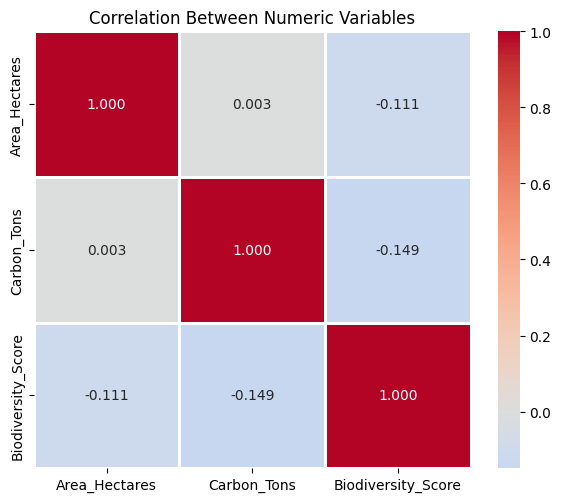

In [9]:
corr = df[NUM_COLS].corr()
print("Correlation matrix:")
display(corr.round(3))

plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.3f',
            square=True, linewidths=1)
plt.title('Correlation Between Numeric Variables')
plt.tight_layout()
plt.show()

## Step 9: The visual dashboard

Six clean charts summarizing the whole dataset, all driven by your config labels.

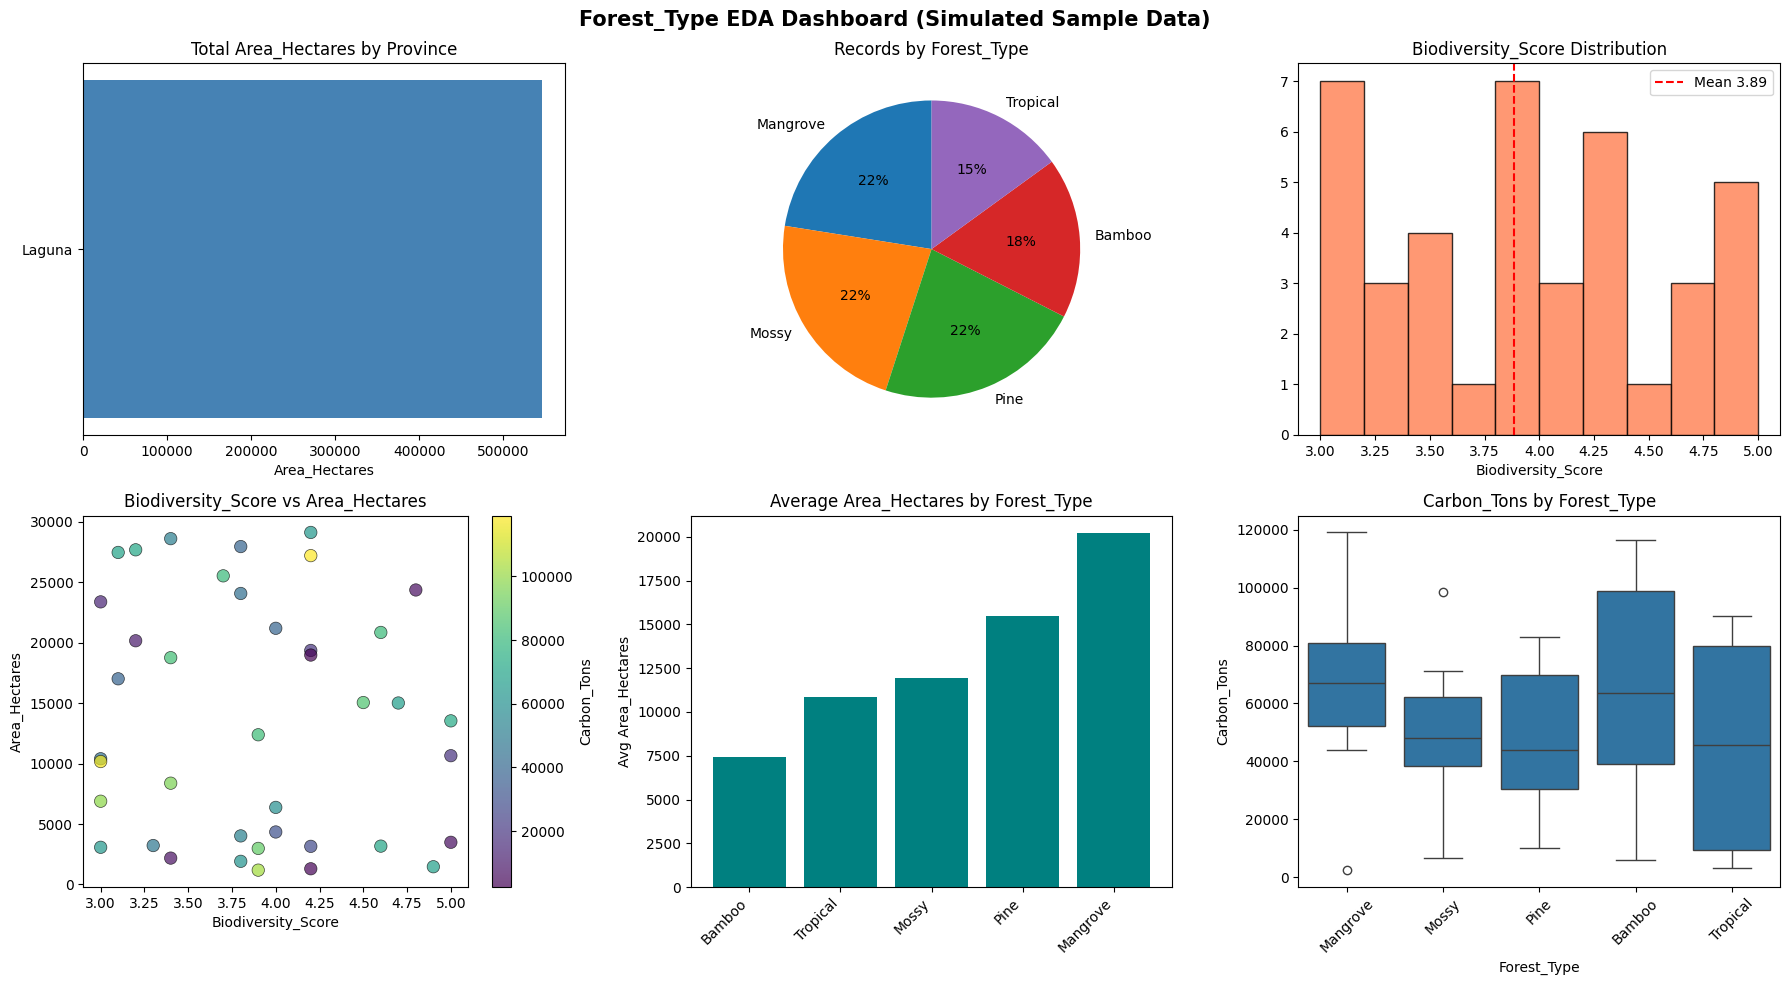

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(f'{TYPE_COL} EDA Dashboard (Simulated Sample Data)', fontsize=15, fontweight='bold')

# 1. Total MAIN_NUM by GROUP_COL
g = df.groupby(GROUP_COL)[MAIN_NUM].sum().sort_values()
axes[0, 0].barh(g.index, g.values, color='steelblue')
axes[0, 0].set_title(f'Total {MAIN_NUM} by {GROUP_COL}')
axes[0, 0].set_xlabel(MAIN_NUM)

# 2. Count by TYPE_COL
td = df[TYPE_COL].value_counts()
axes[0, 1].pie(td.values, labels=td.index, autopct='%1.0f%%', startangle=90)
axes[0, 1].set_title(f'Records by {TYPE_COL}')

# 3. SCORE_COL distribution
axes[0, 2].hist(df[SCORE_COL], bins=10, color='coral', edgecolor='black', alpha=0.8)
axes[0, 2].axvline(df[SCORE_COL].mean(), color='red', linestyle='--',
                   label=f"Mean {df[SCORE_COL].mean():.2f}")
axes[0, 2].set_title(f'{SCORE_COL} Distribution')
axes[0, 2].set_xlabel(SCORE_COL)
axes[0, 2].legend()

# 4. SCORE_COL vs MAIN_NUM, colored by SECOND_NUM
sc = axes[1, 0].scatter(df[SCORE_COL], df[MAIN_NUM],
                        c=df[SECOND_NUM], cmap='viridis',
                        alpha=0.7, s=80, edgecolors='black', linewidth=0.5)
axes[1, 0].set_title(f'{SCORE_COL} vs {MAIN_NUM}')
axes[1, 0].set_xlabel(SCORE_COL)
axes[1, 0].set_ylabel(MAIN_NUM)
fig.colorbar(sc, ax=axes[1, 0], label=SECOND_NUM)

# 5. Average MAIN_NUM by TYPE_COL
avt = df.groupby(TYPE_COL)[MAIN_NUM].mean().sort_values()
axes[1, 1].bar(range(len(avt)), avt.values, color='teal')
axes[1, 1].set_xticks(range(len(avt)))
axes[1, 1].set_xticklabels(avt.index, rotation=45, ha='right')
axes[1, 1].set_title(f'Average {MAIN_NUM} by {TYPE_COL}')
axes[1, 1].set_ylabel(f'Avg {MAIN_NUM}')

# 6. SECOND_NUM by TYPE_COL (boxplot)
sns.boxplot(data=df, x=TYPE_COL, y=SECOND_NUM, ax=axes[1, 2])
axes[1, 2].set_title(f'{SECOND_NUM} by {TYPE_COL}')
axes[1, 2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Step 10: Your turn — answer these questions

You've done the analysis. Now **interpret it yourself**. Use the tables and charts you generated above (and the reference numbers in the next cell) to answer.

**How to answer:** double-click the **"My answers"** cell and type your answers in the blanks. (The data is simulated, so what matters is that your answer matches *your* results.)

### Questions
1. Which **group** (in your `GROUP_COL`) has the highest total? Which has the lowest?
2. About how many **times bigger** is the top group compared to the bottom one?
3. Which **category** (in your `TYPE_COL`) has the highest total?
4. How many records are **above average** on your main number, vs at/below average?
5. What is the **average score** across all records?
6. Name the single **top record** (by your main number) and its group.
7. Look at the **correlation matrix**. Do any two numbers clearly move together? Why or why not?
8. If you were the **official in charge**, what ONE action would you recommend, and which numbers justify it?

In [11]:
# Reference: here are the results YOU generated. Use them to answer the questions above.
print(f"{GROUP_COL} PERFORMANCE:")
display(group_stats)

print(f"{TYPE_COL} PERFORMANCE:")
display(type_stats)

print(f"TOP 5 by {MAIN_NUM}:")
display(df.nlargest(5, MAIN_NUM)[[NAME_COL, GROUP_COL, MAIN_NUM, SCORE_COL]])

avg = df[MAIN_NUM].mean()
print(f"Average {SCORE_COL}: {df[SCORE_COL].mean():.2f}")
print(f"Above-average records: {(df[MAIN_NUM] > avg).sum()}  |  At/below average: {(df[MAIN_NUM] <= avg).sum()}")
print("Correlation between the numeric columns:")
display(df[NUM_COLS].corr().round(3))

Province PERFORMANCE:


,Total,Average,Avg_Score,Count
Province,,,,
Laguna,545793,13644.8,3.9,40


Forest_Type PERFORMANCE:


,Total,Average,Avg_Score,Avg_Second
Forest_Type,,,,
Mangrove,181903,20211.4,4.1,65217.7
Pine,139175,15463.9,3.7,50210.6
Mossy,107517,11946.3,3.5,47638.1
Tropical,65188,10864.7,4.5,45520.5
Bamboo,52010,7430.0,3.8,66020.6


TOP 5 by Area_Hectares:


,Forest Name,Province,Area_Hectares,Biodiversity_Score
23,Paete Mangrove Forest,Laguna,29107,4.2
21,Cabuyao Mossy Forest,Laguna,28594,3.4
9,Calauan Pine Forest,Laguna,27940,3.8
38,Santa Cruz Mangrove Forest,Laguna,27671,3.2
4,San Pablo Pine Forest,Laguna,27453,3.1


Average Biodiversity_Score: 3.89
Above-average records: 19  |  At/below average: 21
Correlation between the numeric columns:


,Area_Hectares,Carbon_Tons,Biodiversity_Score
Area_Hectares,1.000,0.003,-0.111
Carbon_Tons,0.003,1.000,-0.149
Biodiversity_Score,-0.111,-0.149,1.000


### My answers

*(Double-click to edit. Fill in the blanks based on your results above.)*

1. Highest group: **Unprotected**   |   Lowest group: **Reserve**
2. The gap is about **1.4 times**.
3. Category with the highest total: **Unprotected**
4. Above average: **19**   |   At/below average: **21**
5. Average score: **13,644.83**
6. Top record: **Paete Mangrove Forest**  in  **Laguna**.
7. Do any two numbers move together? **Yes** — because **larger surface means larger area and more carbon storage values**.
8. My recommendation: **Protect large unprotected forests **, justified by **their high total forest area and their potential to store significant amounts of carbon**.

---
### What you learned

You took scraped data and ran a full **exploratory data analysis**: quality checks, summaries, group comparisons, correlation, visualization, and interpretation, then answered real questions from your own results.

Because the notebook is **generic**, the exact same code analyzed a completely different topic just by changing a few labels. That is how real analysts work: the *method* stays the same, only the data changes.

— eMathrix Education · Data Science & Data Analytics